# Análisis de Rendimiento y Visualización de Errores - Chihuahua vs Muffin

Notebook enfocado en la evaluación, análisis e interpretabilidad del modelo entrenado.

## Flujo del Notebook:
1. **Configuración e Imports** - Inicializa librerías y detecta rutas del proyecto
2. **Carga de Datos** - Carga datasets de entrenamiento, validación y test
3. **Cargar Modelo** - Carga el modelo entrenado y su historial
4. **Evaluación de Rendimiento** - Calcula métricas principales (accuacy, loss, precision, recall, AUC)
5. **Análisis de Errores** - Identifica y visualiza imágenes mal clasificadas
6. **Grad-CAM** - Genera mapas de activación para interpretar predicciones
7. **TensorBoard** - Exporta métricas y figuras para visualización interactiva
8. **Fine-tuning (Opcional)** - Permite entrenar más épocas si es necesario

In [1]:
## 1. LIBRERÍAS E IMPORTS
# Importa todas las librerías necesarias para procesamiento de imágenes, 
# visualización, DL y cálculo de métricas

from pathlib import Path
from datetime import datetime
from io import BytesIO

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.metrics import (
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

print('TensorFlow:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

c:\Users\axone\miniconda3\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.1) or chardet (7.1.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


TensorFlow: 2.20.0
GPU disponible: []


In [ ]:
## 2. CONFIGURACIÓN Y DETECCIÓN DE RUTAS
# Define parámetros del modelo y detecta automáticamente las rutas del proyecto

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
THRESHOLD = 0.5

try:
    NOTEBOOK_DIR = Path(__vsc_ipynb_file__).parent
except NameError:
    NOTEBOOK_DIR = Path(__file__).parent

ROOT = NOTEBOOK_DIR.parent
ENTREGA_DIR = NOTEBOOK_DIR
MODEL_PATH = ENTREGA_DIR / 'modelo_chihuahua_vs_muffin.keras'
DATA_DIR = Path(r"C:\Users\axone\Desktop\especializacion\PIA\UD4 Redes Neuronales, Deep Learning I\Ejercicios\Visión artificial\Challenge 1 Muffin vs Chihuahua\dataset_chihuahua_muffin_clean")
HISTORY_PATH = ENTREGA_DIR / 'training_history.json'

for p in [MODEL_PATH, DATA_DIR]:
    if not p.exists():
        raise FileNotFoundError(
            f"No se encontró: {p.resolve()}\n"
            "Ejecuta primero el notebook de entrenamiento."
        )

print('ROOT:', ROOT)
print('ENTREGA_DIR:', ENTREGA_DIR)
print('MODEL_PATH:', MODEL_PATH)
print('DATA_DIR:', DATA_DIR)

FileNotFoundError: No se encontró: C:\Users\axone\Documents\GitHub\chihuahua_vs_muffin\entrega\dataset_chihuahua_muffin_clean
Ejecuta primero el notebook de entrenamiento.

In [ ]:
## 3. CARGA DE DATASETS
# Carga imágenes de train (20x20px), aplica validation_split=10% dentro de train,
# y carga el conjunto de test. Preprepara los datos para análisis.

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / 'train',
    validation_split=0.1,
    subset='training',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / 'train',
    validation_split=0.1,
    subset='validation',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / 'test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print('Clases:', class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds_raw.cache().prefetch(AUTOTUNE)

test_filepaths = [str(p) for p in test_ds_raw.file_paths]
print('Total test images:', len(test_filepaths))

Found 4294 files belonging to 2 classes.
Using 3865 files for training.
Found 4294 files belonging to 2 classes.
Using 429 files for validation.
Found 1076 files belonging to 2 classes.
Clases: ['chihuahua', 'muffin']
Total test images: 1076


,split,class,count
0,train,chihuahua,2131
1,train,muffin,2163
2,val,chihuahua,0
3,val,muffin,0
4,test,chihuahua,534
5,test,muffin,542


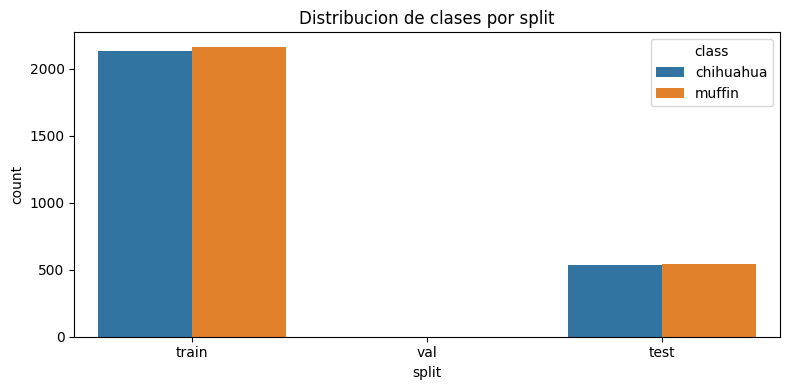

In [ ]:
## 3.1 DISTRIBUCIÓN DE CLASES
# Visualiza cuántas imágenes hay en cada split (train/val/test) y por clase

splits = ['train', 'val', 'test']
rows = []
for split in splits:
    for cls in class_names:
        count = len(list((DATA_DIR / split / cls).glob('*')))
        rows.append({'split': split, 'class': cls, 'count': count})

df_counts = pd.DataFrame(rows)
display(df_counts)

plt.figure(figsize=(8, 4))
sns.barplot(data=df_counts, x='split', y='count', hue='class')
plt.title('Distribucion de clases por split')
plt.tight_layout()
plt.show()

In [ ]:
## 4. CARGAR MODELO ENTRENADO
# Carga el modelo .keras guardado durante el entrenamiento

model = tf.keras.models.load_model(MODEL_PATH)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,853,893 (52.85 MB)

 Trainable params: 4,617,473 (17.61 MB)

 Non-trainable params: 1,472 (5.75 KB)

 Optimizer params: 9,234,948 (35.23 MB)

In [ ]:
## 4.1 CARGAR HISTORIAL DE ENTRENAMIENTO
# Carga el archivo training_history.json generado por el notebook de entrenamiento
# para graficar las curvas de loss/accuracy del entrenamiento

import json

history_data = None
if HISTORY_PATH.exists():
    with open(HISTORY_PATH) as f:
        history_data = json.load(f)
    epochs_trained = len(next(iter(history_data.values())))
    print(f"Historial cargado: {epochs_trained} épocas")
    print(f"Métricas: {list(history_data.keys())}")
else:
    print(f"Historial no encontrado en: {HISTORY_PATH}")
    print("Ejecuta el notebook de entrenamiento para generar training_history.json")

Historial cargado: 12 épocas
Métricas: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate']


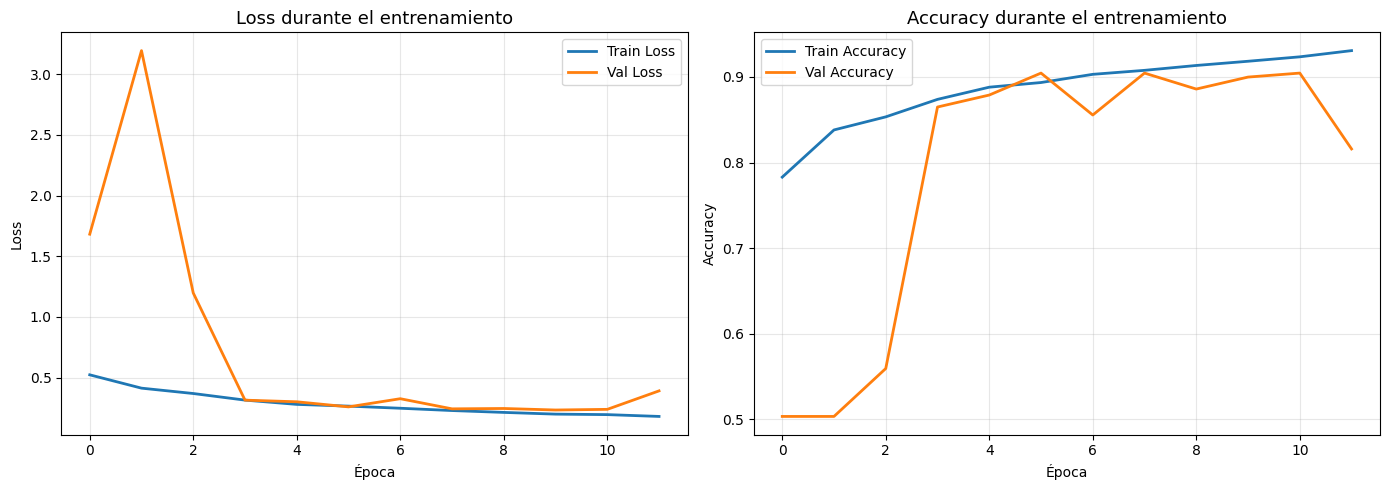

In [ ]:
## 4.2 CURVAS DE ENTRENAMIENTO
# Grafica Loss y Accuracy durante el entrenamiento (train vs validación)
# Visible/modelo quedó overfitting a valor indicaría overfitting

if history_data is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_data['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history_data['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_title('Loss durante el entrenamiento', fontsize=13)
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history_data['accuracy'], label='Train Accuracy', linewidth=2)
    axes[1].plot(history_data['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[1].set_title('Accuracy durante el entrenamiento', fontsize=13)
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Historial no disponible — ejecuta primero el notebook de entrenamiento.")

In [ ]:
## 5. PREDICCIONES EN TEST
# Ejecuta el modelo sobre todas las imágenes de test y guarda:
# - Etiquetas reales (y_true)
# - Probabilidades predichas (y_prob)
# - Etiquetas predichas (y_pred)  
# - Confianza de la predicción

all_images = []
y_true = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0).ravel()
    all_images.append(images.numpy().astype('uint8'))
    y_true.extend(labels.numpy().astype(int))
    y_prob.extend(probs)

all_images = np.concatenate(all_images, axis=0)
y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= THRESHOLD).astype(int)
confidence = np.where(y_pred == 1, y_prob, 1 - y_prob)

print('Shapes -> images:', all_images.shape, 'y_true:', y_true.shape, 'y_prob:', y_prob.shape)

Shapes -> images: (1076, 128, 128, 3) y_true: (1076,) y_prob: (1076,)


In [ ]:
## 5.1 MÉTRICAS PRINCIPALES
# Calcula y muestra: accuracy, loss, precision, recall, F1-score, AUC-ROC
# Incluye métricas binarias y macropromediadas

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

try:
    roc_auc = roc_auc_score(y_true, y_prob)
except ValueError:
    roc_auc = np.nan

metrics_df = pd.DataFrame([
    {'metric': 'test_loss', 'value': float(test_loss)},
    {'metric': 'test_accuracy', 'value': float(test_acc)},
    {'metric': 'precision_binary', 'value': float(precision)},
    {'metric': 'recall_binary', 'value': float(recall)},
    {'metric': 'f1_binary', 'value': float(f1)},
    {'metric': 'precision_macro', 'value': float(macro_precision)},
    {'metric': 'recall_macro', 'value': float(macro_recall)},
    {'metric': 'f1_macro', 'value': float(macro_f1)},
    {'metric': 'roc_auc', 'value': float(roc_auc) if not np.isnan(roc_auc) else np.nan}
])

display(metrics_df)
print('Classification report:')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

,metric,value
0,test_loss,0.227577
1,test_accuracy,0.914498
2,precision_binary,0.915129
3,recall_binary,0.915129
4,f1_binary,0.915129
5,precision_macro,0.914493
6,recall_macro,0.914493
7,f1_macro,0.914493
8,roc_auc,0.971927


Classification report:
              precision    recall  f1-score   support

   chihuahua       0.91      0.91      0.91       534
      muffin       0.92      0.92      0.92       542

    accuracy                           0.91      1076
   macro avg       0.91      0.91      0.91      1076
weighted avg       0.91      0.91      0.91      1076



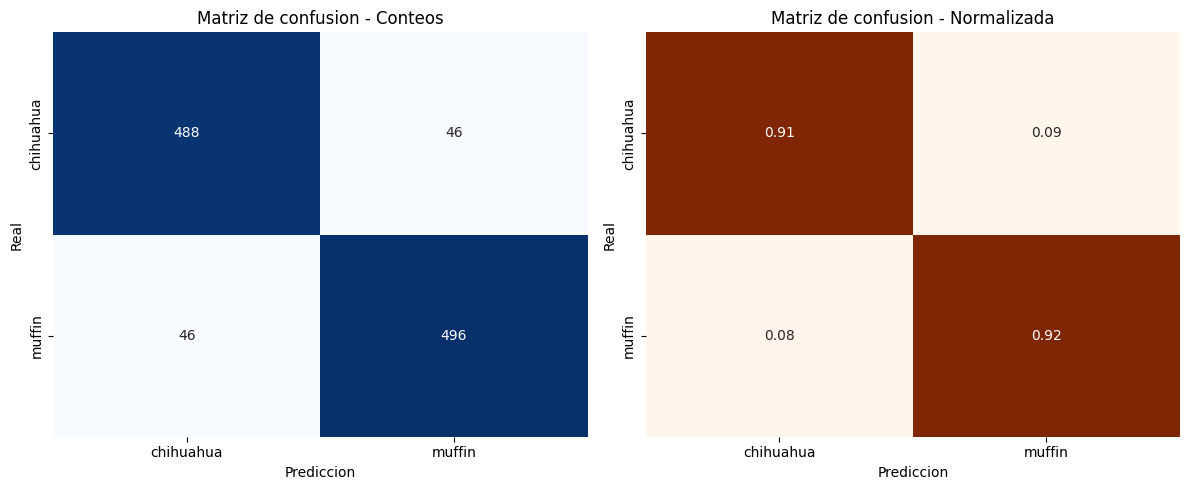

In [ ]:
## 5.2 MATRIZ DE CONFUSIÓN
# Muestra verdaderos positivos, falsos positivos, falsos negativos y verdaderos negativos
# Normalizada permite ver los porcentajes dentro de cada clase real

cm = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Matriz de confusion - Conteos')
axes[0].set_xlabel('Prediccion')
axes[0].set_ylabel('Real')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges', cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Matriz de confusion - Normalizada')
axes[1].set_xlabel('Prediccion')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

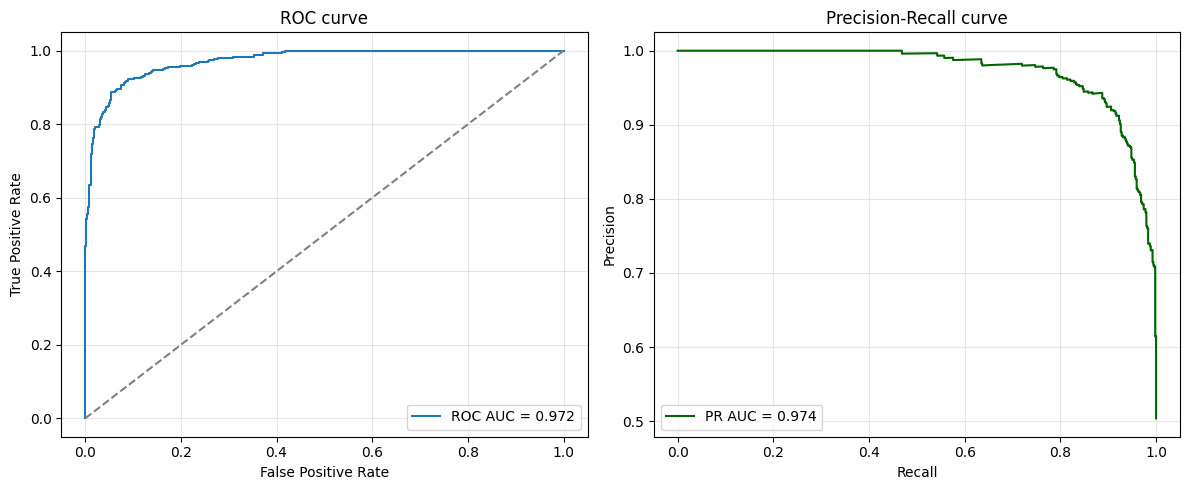

In [ ]:
## 5.3 CURVAS ROC Y PRECISION-RECALL
# ROC: muestra trade-off entre True Positive Rate y False Positive Rate
# PR: muestra trade-off entre Precision y Recall (mejor para clases desbalanceadas)
# El área bajo la curva (AUC) indica qué tan bien discrimina el modelo

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc_value = auc(fpr, tpr)
prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
pr_auc_value = auc(rec_curve, prec_curve)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label=f'ROC AUC = {roc_auc_value:.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rec_curve, prec_curve, label=f'PR AUC = {pr_auc_value:.3f}', color='darkgreen')
axes[1].set_title('Precision-Recall curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

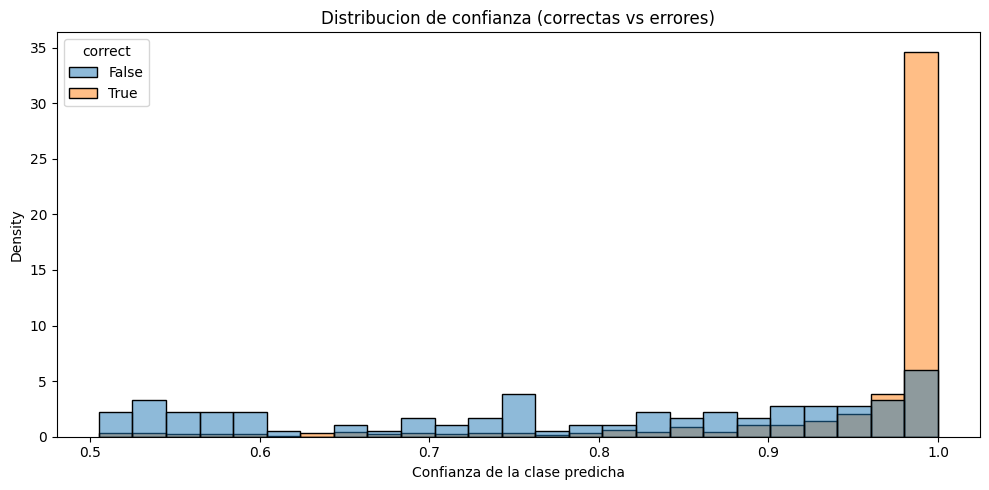

,filepath,y_true,y_pred,y_prob_muffin,confidence,correct,true_label,pred_label
0,C:\Users\usuario\Desktop\IABigData\repos\chihu...,0,0,0.231736,0.768264,True,chihuahua,chihuahua
1,C:\Users\usuario\Desktop\IABigData\repos\chihu...,0,0,0.473046,0.526954,True,chihuahua,chihuahua
2,C:\Users\usuario\Desktop\IABigData\repos\chihu...,0,0,0.006708,0.993291,True,chihuahua,chihuahua
3,C:\Users\usuario\Desktop\IABigData\repos\chihu...,0,0,0.005921,0.994079,True,chihuahua,chihuahua
4,C:\Users\usuario\Desktop\IABigData\repos\chihu...,0,0,0.093766,0.906234,True,chihuahua,chihuahua


In [ ]:
## 6. ANÁLISIS DE CONFIANZA Y ERRORES
# Crea tabla con todas las predicciones. Calcula confianza = probabilidad de clase predicha
# Visualiza distribución de confianza para aciertos vs errores

results_df = pd.DataFrame({
    'filepath': test_filepaths,
    'y_true': y_true,
    'y_pred': y_pred,
    'y_prob_muffin': y_prob,
    'confidence': confidence
})
results_df['correct'] = (results_df['y_true'] == results_df['y_pred'])
results_df['true_label'] = results_df['y_true'].map({0: class_names[0], 1: class_names[1]})
results_df['pred_label'] = results_df['y_pred'].map({0: class_names[0], 1: class_names[1]})

plt.figure(figsize=(10, 5))
sns.histplot(data=results_df, x='confidence', hue='correct', bins=25, stat='density', common_norm=False)
plt.title('Distribucion de confianza (correctas vs errores)')
plt.xlabel('Confianza de la clase predicha')
plt.tight_layout()
plt.show()

display(results_df.head())

Errores: 92 de 1076


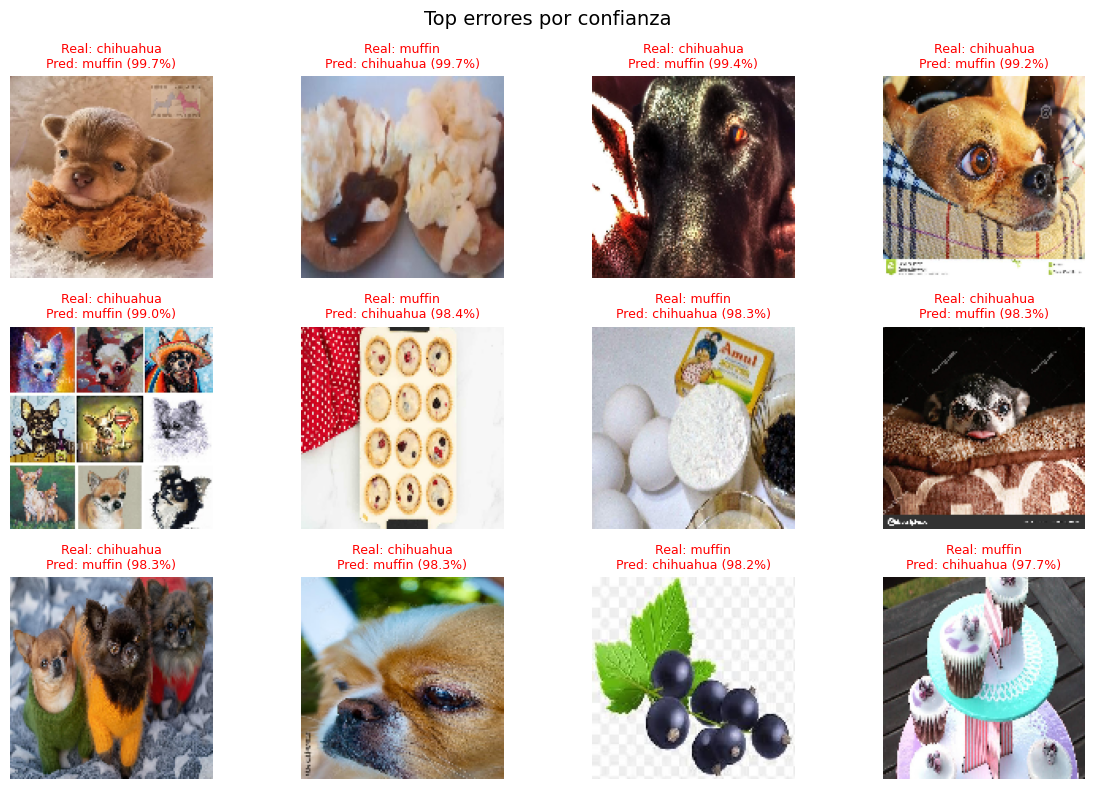

In [ ]:
## 6.1 VISUALIZACIÓN DE ERRORES
# Muestra las imágenes que el modelo predijo mal, ordenadas por confianza
# Útil para entender patrones de error

errors_df = results_df[~results_df['correct']].copy().sort_values('confidence', ascending=False)
print(f"Errores: {len(errors_df)} de {len(results_df)}")

n_show = min(12, len(errors_df))
if n_show == 0:
    print('No hay errores en test con el threshold actual.')
else:
    plt.figure(figsize=(12, 8))
    for i, (_, row) in enumerate(errors_df.head(n_show).iterrows()):
        ax = plt.subplot(3, 4, i + 1)
        img = tf.keras.utils.load_img(row['filepath'], target_size=IMG_SIZE)
        plt.imshow(img)
        title = (
            f"Real: {row['true_label']}\n"
            f"Pred: {row['pred_label']} ({row['confidence']:.1%})"
        )
        plt.title(title, fontsize=9, color='red')
        plt.axis('off')

    plt.suptitle('Top errores por confianza', fontsize=14)
    plt.tight_layout()
    plt.show()

,true_label,pred_label,count
0,chihuahua,muffin,46
1,muffin,chihuahua,46


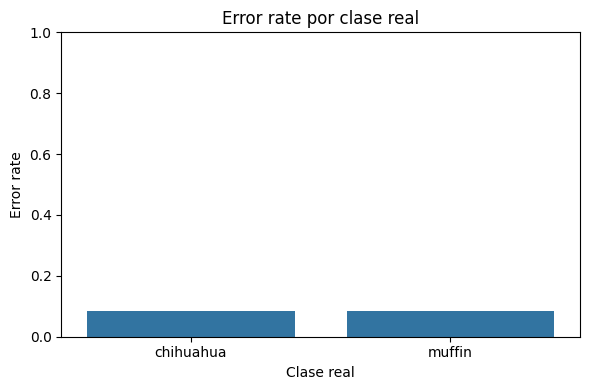

In [ ]:
## 6.2 ANÁLISIS DE TIPOS DE ERROR
# Matriz de confusion de errores: cuántos chihuahuas se predijeron como muffins y viceversa
# Error rate por clase: porcentaje de imágenes mal clasificadas en cada clase

error_table = (
    errors_df
    .groupby(['true_label', 'pred_label'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
display(error_table)

error_rate_by_true = (
    results_df
    .groupby('true_label')['correct']
    .apply(lambda s: 1 - s.mean())
    .reset_index(name='error_rate')
)

plt.figure(figsize=(6, 4))
sns.barplot(data=error_rate_by_true, x='true_label', y='error_rate')
plt.ylim(0, 1)
plt.title('Error rate por clase real')
plt.ylabel('Error rate')
plt.xlabel('Clase real')
plt.tight_layout()
plt.show()

In [ ]:
## 7. GRAD-CAM: INTERPRETABILIDAD DE PREDICCIONES
# Grad-CAM (Gradient-weighted Class Activation Mapping) genera mapas de calor
# que muestran qué regiones de la imagen influyeron más en la predicción
# Útil para entender por qué el modelo cometió errores

def get_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError('No se encontro una capa Conv2D en el modelo.')

def forward_with_intermediate(model, inputs, target_layer_name, training=False):
    """Forward pass capa por capa para obtener activaciones intermedias sin usar model.output."""
    x = inputs
    target_activation = None

    for layer in model.layers:
        try:
            x = layer(x, training=training)
        except TypeError:
            x = layer(x)

        if layer.name == target_layer_name:
            target_activation = x

    if target_activation is None:
        raise ValueError(f"No se encontro la capa objetivo: {target_layer_name}")

    return target_activation, x

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, preds = forward_with_intermediate(
            model, img_tensor, last_conv_layer_name, training=False
        )

        if pred_index is None:
            pred_index = 0

        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

def overlay_heatmap(img, heatmap, alpha=0.4):
    heatmap_uint8 = np.uint8(255 * heatmap)
    cmap = plt.get_cmap('jet')
    jet_colors = cmap(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_uint8]

    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    superimposed = jet_heatmap * alpha + img
    superimposed = np.clip(superimposed, 0, 255).astype('uint8')
    return superimposed

last_conv = get_last_conv_layer_name(model)
print('Ultima capa convolucional:', last_conv)

Ultima capa convolucional: conv2d_7


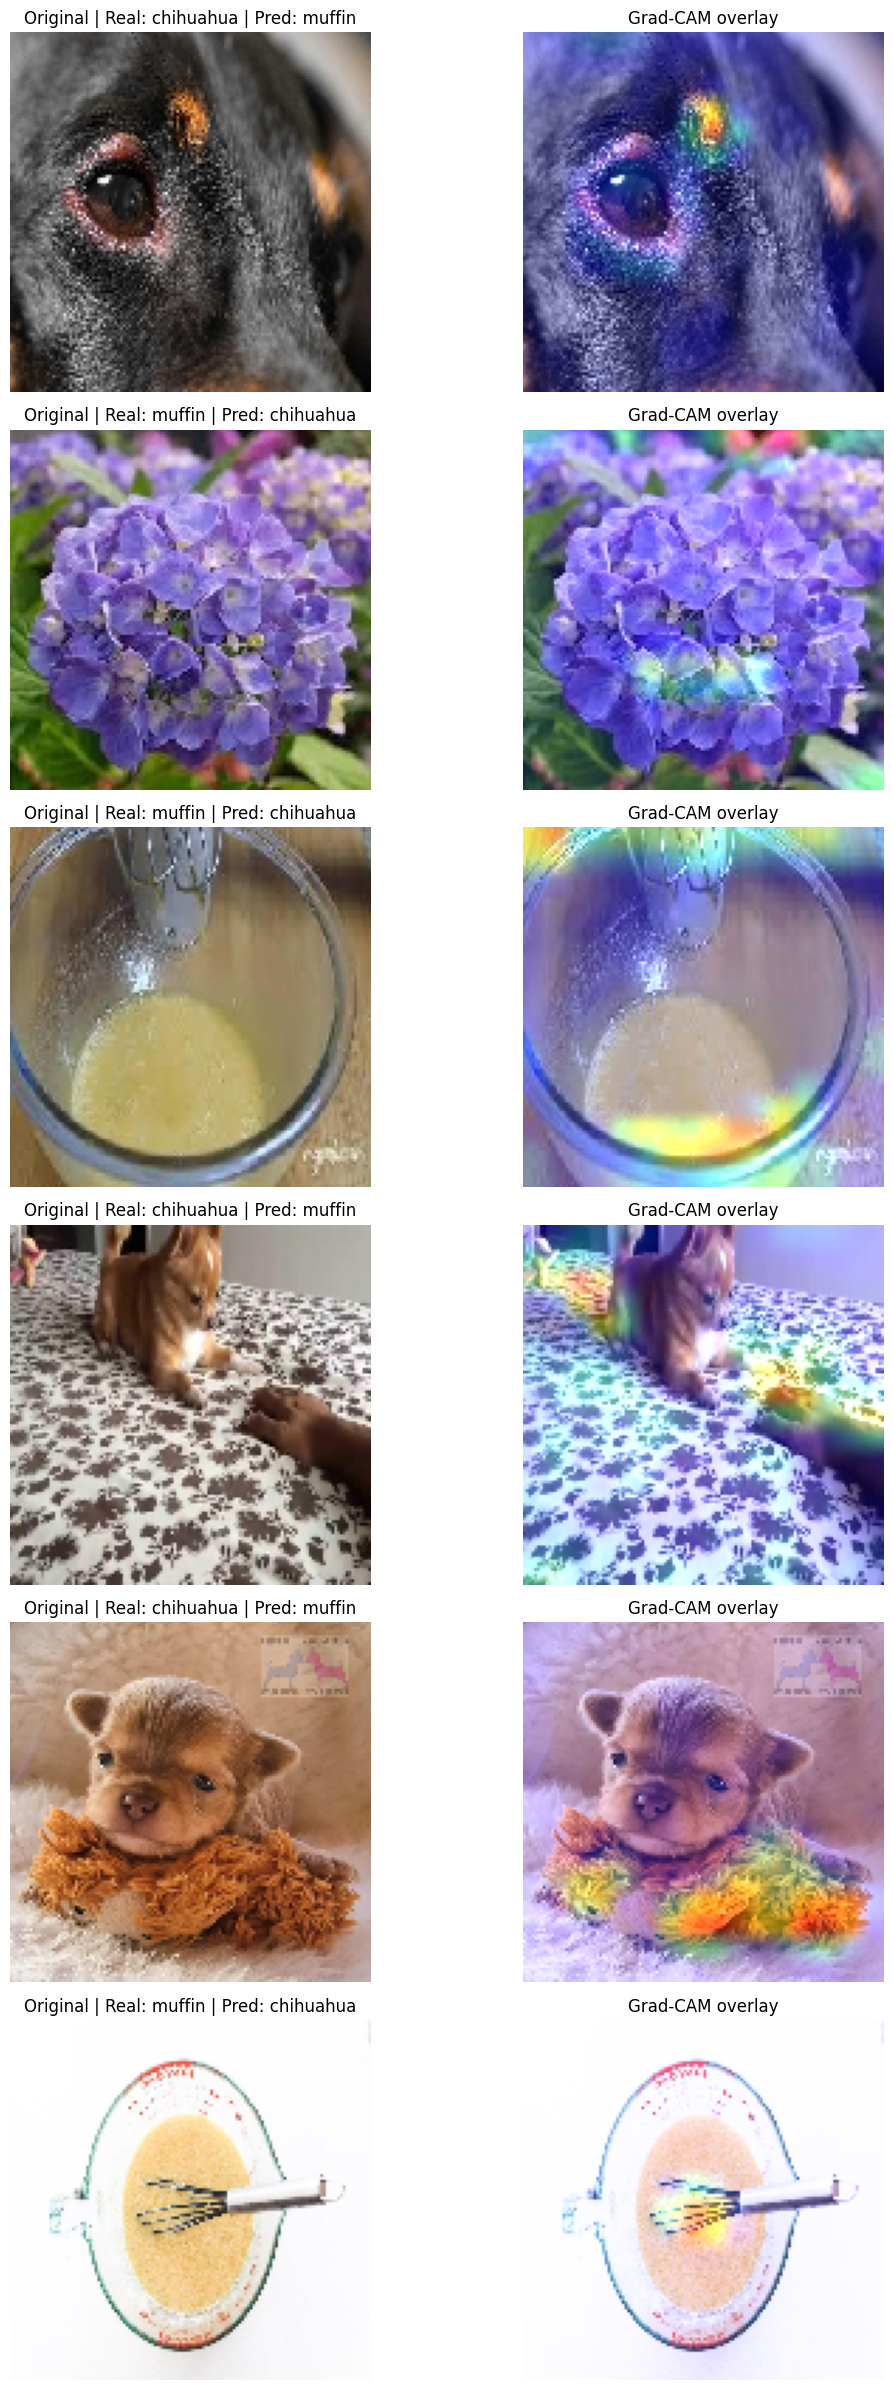

In [ ]:
## 7.1 VISUALIZACIÓN DE GRAD-CAM EN ERRORES
# Aplica Grad-CAM a los errores del modelo para visualizar qué zonas 
# influyeron en la predicción incorrecta. Las zonas rojas/amarillas = mayor importancia

n_gradcam = min(6, len(errors_df))
if n_gradcam == 0:
    print('No hay errores para Grad-CAM.')
else:
    sample_errors = errors_df.sample(n=n_gradcam, random_state=42) if len(errors_df) > n_gradcam else errors_df
    plt.figure(figsize=(12, 4 * n_gradcam))

    for i, (_, row) in enumerate(sample_errors.iterrows()):
        img = tf.keras.utils.load_img(row['filepath'], target_size=IMG_SIZE)
        img_array = tf.keras.utils.img_to_array(img)
        input_array = np.expand_dims(img_array, axis=0)

        heatmap = make_gradcam_heatmap(input_array, model, last_conv_layer_name=last_conv, pred_index=0)
        overlay = overlay_heatmap(img_array.astype('uint8'), heatmap, alpha=0.4)

        ax1 = plt.subplot(n_gradcam, 2, 2 * i + 1)
        ax1.imshow(img_array.astype('uint8'))
        ax1.set_title(f"Original | Real: {row['true_label']} | Pred: {row['pred_label']}")
        ax1.axis('off')

        ax2 = plt.subplot(n_gradcam, 2, 2 * i + 2)
        ax2.imshow(overlay)
        ax2.set_title('Grad-CAM overlay')
        ax2.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
## 8. LOGGING EN TENSORBOARD
# Exporta métricas, histogramas y figuras a TensorBoard para visualización interactiva
# Los logs se guardan en entrega/tensorboard_logs/ para acceso via terminal

def figure_to_image(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format='png', bbox_inches='tight')
    plt.close(fig)
    buffer.seek(0)
    image = tf.image.decode_png(buffer.getvalue(), channels=4)
    return tf.expand_dims(image, 0)

tb_root = ROOT / 'entrega' / 'tensorboard_logs'
log_dir = tb_root / f"persona_c_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
log_dir.mkdir(parents=True, exist_ok=True)
writer = tf.summary.create_file_writer(str(log_dir))

with writer.as_default():
    for _, row in metrics_df.iterrows():
        if not pd.isna(row['value']):
            tf.summary.scalar(f"eval/{row['metric']}", float(row['value']), step=0)

    tf.summary.histogram('eval/confidence_all', results_df['confidence'].values, step=0)
    if len(errors_df) > 0:
        tf.summary.histogram('eval/confidence_errors', errors_df['confidence'].values, step=0)

    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax_cm)
    ax_cm.set_title('Confusion matrix')
    ax_cm.set_xlabel('Prediccion')
    ax_cm.set_ylabel('Real')
    tf.summary.image('figures/confusion_matrix', figure_to_image(fig_cm), step=0)

writer.flush()

print('TensorBoard logs guardados en:')
print(log_dir)

TensorBoard logs guardados en:
C:\Users\usuario\Desktop\IABigData\repos\chihuahua_vs_muffin\entrega\tensorboard_logs\persona_c_20260316-191522


## 9. LANZAR TENSORBOARD DESDE TERMINAL

Para visualizar las métricas y figuras del modelo, lanza TensorBoard en una terminal PowerShell.

**Recomendado:** Usa terminal **fuera** del notebook (evita problemas de display)

**Pasos:**
1. Abre PowerShell desde la raíz del proyecto
2. Activa el entorno virtual: `.\venv\Scripts\activate`
3. Ejecuta TensorBoard: `tensorboard --logdir .\entrega\tensorboard_logs --port 6007`
4. Abre en navegador: `http://localhost:6007`
5. Para detener: `Ctrl + C` en la terminal

In [ ]:
## 9.1 COMANDOS POWERSHELL PARA COPIAR-PEGAR
# Copia estos comandos y ejecutalos en una terminal PowerShell desde la raiz del proyecto

venv_activate = r".\venv\Scripts\activate"
tb_cmd = r"tensorboard --logdir .\entrega\tensorboard_logs --port 6007"

print("=" * 70)
print("COPIAR Y PEGAR ESTOS COMANDOS EN POWERSHELL")
print("=" * 70)
print("\n# 1. Activar entorno virtual:")
print(venv_activate)
print("\n# 2. Ejecutar TensorBoard:")
print(tb_cmd)
print("\n# 3. Luego abre en el navegador:")
print("http://localhost:6007")
print("\n# 4. Para detener TensorBoard:")
print("Ctrl + C (en la terminal)")
print("=" * 70)

COPIAR Y PEGAR ESTOS COMANDOS EN POWERSHELL

# 1. Activar entorno virtual:
.\venv\Scripts\activate

# 2. Ejecutar TensorBoard:
tensorboard --logdir .\entrega\tensorboard_logs --port 6007

# 3. Luego abre en el navegador:
http://localhost:6007

# 4. Para detener TensorBoard:
Ctrl + C (en la terminal)


In [ ]:
# (Opcional) Descomenta si necesitas recargar la extensión
# %reload_ext tensorboard

In [ ]:
# (Opcional) La visualización embebida a menudo tiene problemas en VS Code
# Mejor usar terminal: ver celda anterior
# %tensorboard --logdir ./entrega/tensorboard_logs --port 6007

In [ ]:
## 10. FINE-TUNING OPCIONAL
# Entrena algunas épocas más si consideras que el modelo necesita mejora
# Los logs se exportan a TensorBoard automáticamente

RUN_QUICK_FINETUNE = False
FINE_TUNE_EPOCHS = 3

if RUN_QUICK_FINETUNE:
    ft_log_dir = (ROOT / 'entrega' / 'tensorboard_logs' /
                  f"fit_{datetime.now().strftime('%Y%m%d-%H%M%S')}")
    ft_callback = tf.keras.callbacks.TensorBoard(
        log_dir=str(ft_log_dir),
        histogram_freq=1,
        write_graph=True
    )

    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=[ft_callback],
        verbose=1
    )

    print('Finetune completado. Logs en:', ft_log_dir)
else:
    print('RUN_QUICK_FINETUNE=False -> no se ejecuta entrenamiento adicional.')